In [2]:
import sys
%pip install seaborn xgboost mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


**Imports And Cofiguration**

In [3]:
# Importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MLflow
import mlflow
import mlflow.sklearn

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report # Imported but used for classification 

import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print(f"MLflow Version: {mlflow.__version__}")

# Set MLflow Experiment
mlflow.set_experiment("Earthquake_Prediction")

MLflow Version: 3.7.0


2025/12/21 07:48:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/21 07:48:07 INFO mlflow.store.db.utils: Updating database tables
2025/12/21 07:48:07 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/21 07:48:07 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/21 07:48:07 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/21 07:48:07 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='file:c:/Users/WinDows/Downloads/mlruns/2', creation_time=1766257318987, experiment_id='2', last_update_time=1766257318987, lifecycle_stage='active', name='Earthquake_Prediction', tags={'mlflow.experimentKind': 'custom_model_development'}>

**Load Data**

In [4]:
# Load dataset
df = pd.read_csv(r"earthquake.csv") 

# Display basic info
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
df.head()

Dataset Shape: (2719, 4)

Column Names: ['Latitude', 'Longitude', 'Depth', 'Magnitude']


,Latitude,Longitude,Depth,Magnitude
0,29.06,77.42,5.0,2.5
1,19.93,72.92,5.0,2.4
2,31.50,74.37,33.0,3.4
3,28.34,76.23,5.0,3.1
4,27.09,89.97,10.0,2.1


**Data Cleaning & Preprocessing**

In [5]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Fill or drop missing values depending on data quality
df = df.dropna()

# Detect categorical columns (if any) and encode
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target
X = df.drop('Magnitude', axis=1)
y = df['Magnitude']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Missing values per column:
 Latitude     0
Longitude    0
Depth        0
Magnitude    0
dtype: int64


**Exploratory Data Analysis (EDA)**

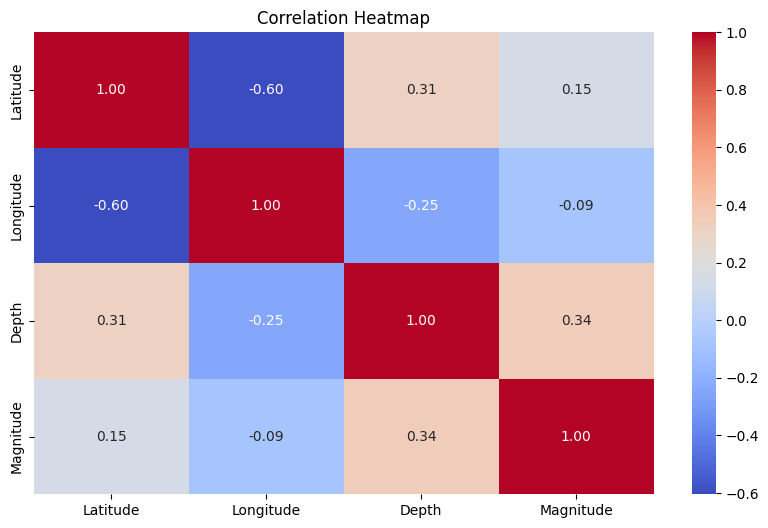

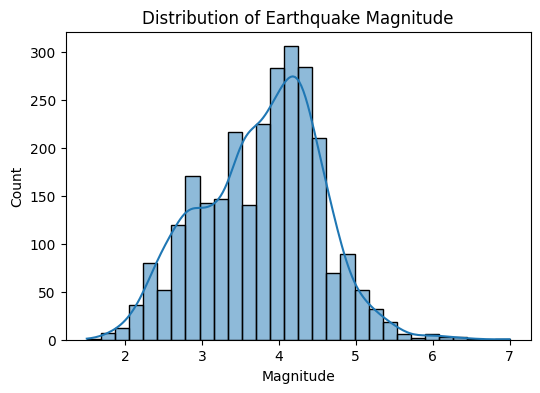

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=True,        
    fmt=".2f"         
)
plt.title("Correlation Heatmap")
plt.show()

# Distribution of target variable
plt.figure(figsize=(6, 4))
sns.histplot(y, bins=30, kde=True)
plt.title("Distribution of Earthquake Magnitude")
plt.show()

**Model Training & MLflow Tracking**

In [7]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import numpy as np
import pandas as pd

results = []

for name, model in models.items():
    with mlflow.start_run(run_name=name):

        # ===============================
        # Regression Training & Prediction
        # ===============================
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

        mae = mean_absolute_error(y_test, preds)
        mse = mean_squared_error(y_test, preds)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, preds)

        n = X_test.shape[0]
        p = X_test.shape[1]
        adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
        accuracy = (1 - mae / np.mean(y_test)) * 100

        results.append([name, mae, mse, rmse, r2, adj_r2, accuracy])

        # ===============================
        # Log metrics
        # ===============================
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("MSE", mse)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)
        mlflow.log_metric("Adjusted_R2", adj_r2)
        mlflow.log_metric("Accuracy", accuracy)

        # ===============================
        # Log model
        # ===============================
        mlflow.sklearn.log_model(model, name.replace(" ", "_"))

        # ===============================
        # Regression Scatter Plot (Actual vs Predicted)
        # ===============================
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=y_test, y=preds)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.title(f"Regression Plot - {name}")
        scatter_path = f"regression_scatter_{name.replace(' ', '_')}.png"
        plt.savefig(scatter_path)
        plt.close()
        mlflow.log_artifact(scatter_path)

        # ===============================
        # Residuals Plot
        # ===============================
        residuals = y_test - preds
        plt.figure(figsize=(6,4))
        sns.histplot(residuals, kde=True)
        plt.xlabel("Residuals")
        plt.title(f"Residuals Distribution - {name}")
        residuals_path = f"residuals_{name.replace(' ', '_')}.png"
        plt.savefig(residuals_path)
        plt.close()
        mlflow.log_artifact(residuals_path)

    

# ===============================
# Display Regression Results Table
# ===============================
results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'R²', 'Adjusted R²', 'Accuracy (%)']
)
results_df.sort_values(by='R²', ascending=False, inplace=True)
display(results_df.style.background_gradient(cmap='Blues', subset=['R²', 'Adjusted R²', 'Accuracy (%)']))

2025/12/21 07:48:16 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2025/12/21 07:48:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instea

,Model,MAE,MSE,RMSE,R²,Adjusted R²,Accuracy (%)
2,Gradient Boosting,0.410213,0.291379,0.539796,0.504554,0.501802,89.277014
1,Random Forest,0.421528,0.310797,0.557492,0.471537,0.468601,88.981249
3,XGBoost,0.438166,0.320506,0.566132,0.455030,0.452002,88.546343
5,KNN,0.428529,0.323353,0.568641,0.450188,0.447134,88.798232
4,SVR,0.440947,0.332513,0.576639,0.434613,0.431472,88.473623
0,Linear Regression,0.581477,0.554627,0.744733,0.056943,0.051704,84.800188


**Visualization of Results**

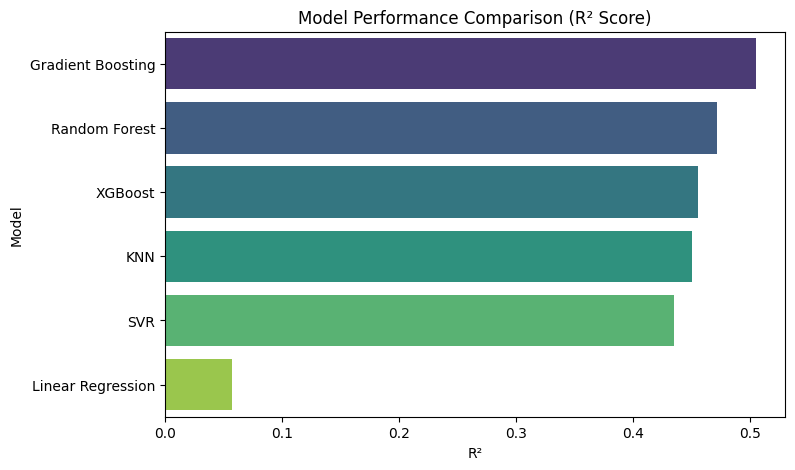

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x='R²', y='Model', data=results_df, palette='viridis')
plt.title("Model Performance Comparison (R² Score)")
plt.show()

**Best Model**

In [9]:
# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

# Retrain best model on all data (Train set)
best_model.fit(X_train_scaled, y_train)

# Save model and scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"Best Model: {best_model_name} saved successfully!")

Best Model: Gradient Boosting saved successfully!


**Feature Importance**

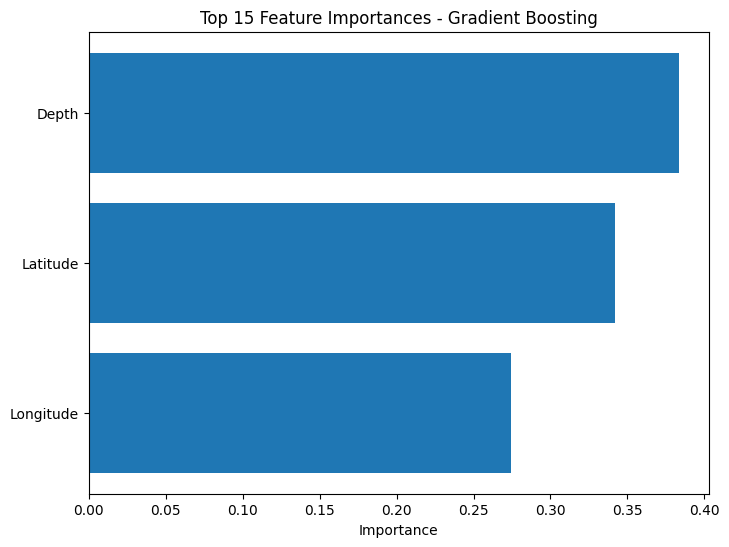

In [10]:
if best_model_name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    importances = best_model.feature_importances_
    features = X.columns
    sorted_idx = np.argsort(importances)[-15:]  # Top 15

    plt.figure(figsize=(8,6))
    plt.barh(features[sorted_idx], importances[sorted_idx])
    plt.title(f"Top 15 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.show()

**Prediction Analysis**

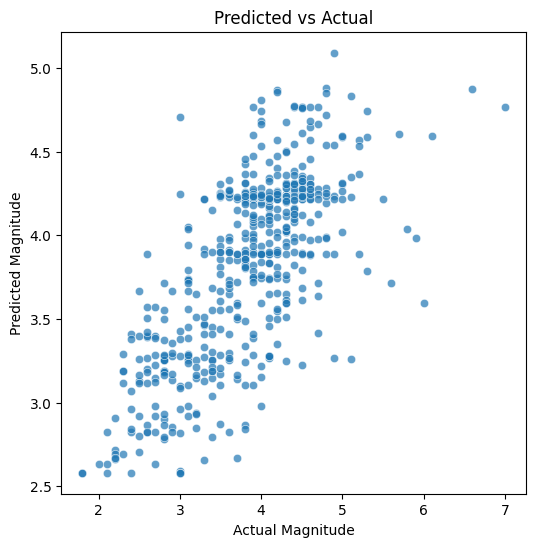

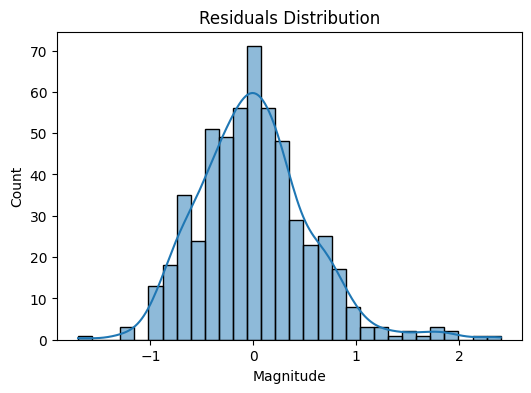

In [11]:
# Predictions on test set
y_pred = best_model.predict(X_test_scaled)
residuals = y_test - y_pred

# Predicted vs Actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Predicted vs Actual")
plt.show()

# Residuals distribution
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residuals Distribution")
plt.show()

**Cross Validation**

In [12]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(best_model, X_train_scaled, y_train, cv=kfold, scoring='r2')

print(f"Cross-Validation R² Scores: {cv_results}")
print(f"Mean CV R²: {cv_results.mean():.4f} ± {cv_results.std():.4f}")

Cross-Validation R² Scores: [0.46066497 0.4837363  0.49476121 0.56375805 0.49923599]
Mean CV R²: 0.5004 ± 0.0344


In [ ]:
!python -m mlflow ui